In [14]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import trange

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from obstacles import create_obstacle_data
from utils.config import Config
from utils.tools import calc_sig_strength_gpu

path_ls = ['Portenta', 'nano', 'orin', 'rbp4', 'rbp5']
data_dict = {}

path_ls

['Portenta', 'nano', 'orin', 'rbp4', 'rbp5']

In [15]:
for path in path_ls:
    data_ls = sorted(os.listdir(f'./{path}'))
    data_dict[path] = {}
    for data in data_ls:
        data_dict[path][data] = pd.read_csv(f'./{path}/{data}')

data_dict

{'Portenta': {'Portenta_tflite.csv':               0          1          3          4          6          7  \
  0     33.381440 -94.929860 -31.561827  67.949844  61.204437 -54.869335   
  1    -28.463003   2.524866  80.478230  89.652214 -44.827100  80.793015   
  2    -88.039970 -13.227165 -49.662334  62.459755  53.099747   5.650627   
  3     90.250110  99.304985 -82.832886 -75.337975 -85.579155 -94.265480   
  4    -17.023457  34.695500   1.025011  83.458660  93.074470  44.745056   
  ...         ...        ...        ...        ...        ...        ...   
  9995 -19.042177  17.697973 -12.094292 -51.694046 -45.294815  25.088392   
  9996 -82.162445  10.696586   2.880204 -46.586002  85.521680 -92.036150   
  9997   2.044212  94.413240  13.454857  14.408174  37.621548 -95.669495   
  9998  52.919190  90.435260   4.891659  22.177473 -75.067604 -64.828224   
  9999  22.090538  17.805012 -34.323150 -27.451689 -86.223785 -40.447533   
  
                9         10         12         13

In [16]:
df_ls = data_dict['orin']
df_ls.keys()

dict_keys(['orin_tensorRT.csv', 'orin_tflite.csv', 'orin_tflite_fp16.csv', 'orin_tflite_int8.csv', 'orin_torch.csv'])

In [17]:
# data_dict 내용 확인
print("data_dict 키들:", list(data_dict.keys()))
print("\ndata_dict 내용:")
for key, value in data_dict.items():
    print(f"{key}: {type(value)}")
    if isinstance(value, pd.DataFrame):
        print(f"  - DataFrame shape: {value.shape}")
        print(f"  - Columns: {list(value.columns)}")
        if 'inference_time_ms' in value.columns:
            print(f"  - inference_time_ms 평균: {value['inference_time_ms'].mean():.2f} ms")
    print()

data_dict 키들: ['Portenta', 'nano', 'orin', 'rbp4', 'rbp5']

data_dict 내용:
Portenta: <class 'dict'>

nano: <class 'dict'>

orin: <class 'dict'>

rbp4: <class 'dict'>

rbp5: <class 'dict'>



In [18]:
# inference_time_ms 평균값 추출 및 시각화
inference_data = {}

for device, device_data in data_dict.items():
    if isinstance(device_data, dict):
        for file_key, df in device_data.items():
            if isinstance(df, pd.DataFrame) and 'inference_time_ms' in df.columns:
                avg_time = df['inference_time_ms'].mean()
                key = f"{device}_{file_key}"
                inference_data[key] = avg_time
                print(f"{key}: {avg_time:.2f} ms")

print(f"\n총 {len(inference_data)}개 파일의 inference_time_ms 평균값을 추출했습니다.")

Portenta_Portenta_tflite.csv: 3.97 ms
Portenta_Portenta_tflite_fp16.csv: 3.96 ms
Portenta_Portenta_tflite_int8.csv: 2.47 ms
Portenta_Portenta_torch.csv: 19.12 ms
nano_nano_tensorRT.csv: 1.10 ms
nano_nano_tflite.csv: 3.10 ms
nano_nano_tflite_fp16.csv: 3.22 ms
nano_nano_tflite_int8.csv: 2.39 ms
nano_nano_torch.csv: 3.24 ms
orin_orin_tensorRT.csv: 0.58 ms
orin_orin_tflite.csv: 1.16 ms
orin_orin_tflite_fp16.csv: 1.18 ms
orin_orin_tflite_int8.csv: 0.27 ms
orin_orin_torch.csv: 1.71 ms
rbp4_rbp4_tflite.csv: 3.43 ms
rbp4_rbp4_tflite_fp16.csv: 3.40 ms
rbp4_rbp4_tflite_int8.csv: 1.04 ms
rbp4_rbp4_torch.csv: 18.20 ms
rbp5_rbp5_tflite.csv: 0.87 ms
rbp5_rbp5_tflite_fp16.csv: 0.87 ms
rbp5_rbp5_tflite_int8.csv: 0.24 ms
rbp5_rbp5_torch.csv: 9.02 ms

총 22개 파일의 inference_time_ms 평균값을 추출했습니다.


In [19]:
# 데이터 정리 및 시각화 준비
df_viz = []
for key, avg_time in inference_data.items():
    parts = key.split('_')
    device = parts[0]
    model_info = '_'.join(parts[2:])  # 모델 타입 정보 (tflite, torch, tensorRT 등)
    
    df_viz.append({
        'Device': device,
        'Model_Type': model_info.replace('.csv', ''),
        'Inference_Time_ms': avg_time,
        'Full_Name': key
    })

df_plot = pd.DataFrame(df_viz)
print("시각화용 데이터프레임:")
print(df_plot)

시각화용 데이터프레임:
      Device   Model_Type  Inference_Time_ms  \
0   Portenta       tflite           3.966446   
1   Portenta  tflite_fp16           3.963890   
2   Portenta  tflite_int8           2.471005   
3   Portenta        torch          19.117695   
4       nano     tensorRT           1.100055   
5       nano       tflite           3.101565   
6       nano  tflite_fp16           3.222764   
7       nano  tflite_int8           2.390698   
8       nano        torch           3.241800   
9       orin     tensorRT           0.577642   
10      orin       tflite           1.158769   
11      orin  tflite_fp16           1.183556   
12      orin  tflite_int8           0.271211   
13      orin        torch           1.711360   
14      rbp4       tflite           3.431814   
15      rbp4  tflite_fp16           3.399284   
16      rbp4  tflite_int8           1.036836   
17      rbp4        torch          18.198967   
18      rbp5       tflite           0.874790   
19      rbp5  tflite_fp16  

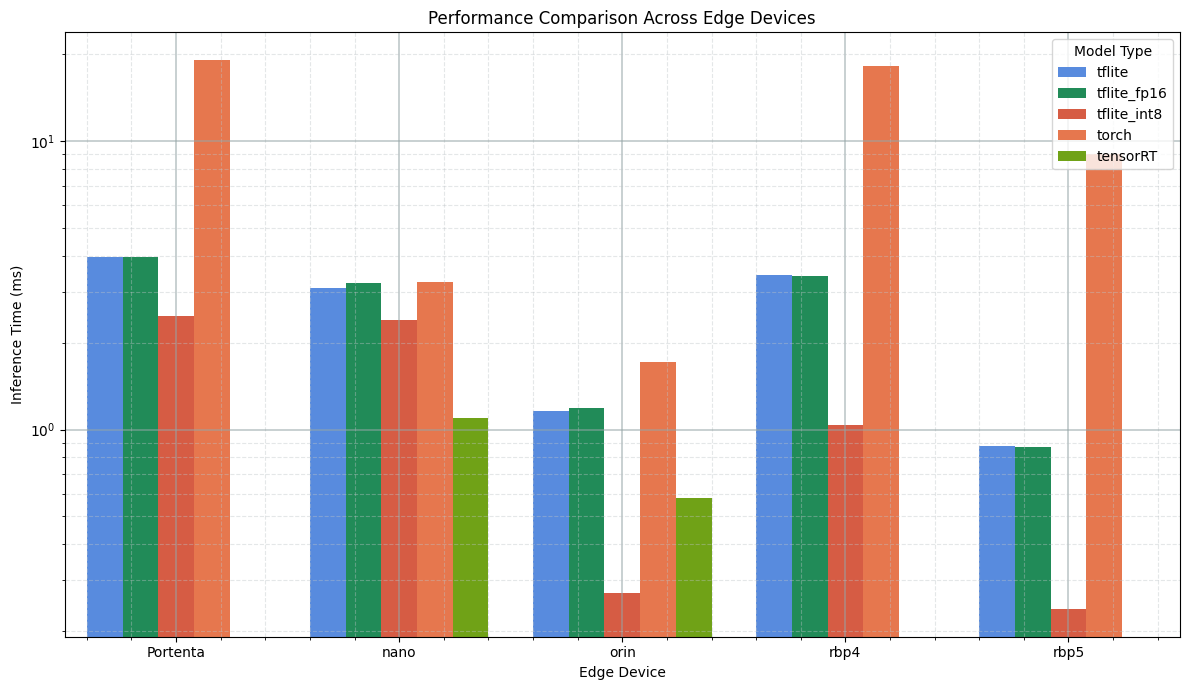

In [20]:
# 브랜드 색상 팔레트 정의
# 순서: ['tflite_fp16', 'tflite_int8', 'torch', 'tflite', 'tensorRT']
brand_colors = {
    'tflite_fp16': '#4285F4',    # Google Blue (TensorFlow Lite)
    'tflite_int8': '#0F9D58',    # Google Green (TensorFlow Lite quantized)
    'torch': '#EE4C2C',          # PyTorch Orange
    'tflite': '#FF6B35',         # Orange Red
    'tensorRT': '#76B900'        # NVIDIA Green
}

# 순서에 맞게 색상 리스트 생성
model_order = ['tflite_fp16', 'tflite_int8', 'torch', 'tflite', 'tensorRT']
custom_colors = [brand_colors[model] for model in model_order]

# 기본 차트 생성
fig, ax = plt.subplots(figsize=(12, 7))

# 바 차트 생성 (브랜드 색상 적용)
sns.barplot(data=df_plot, x='Device', y='Inference_Time_ms', hue='Model_Type', 
           ax=ax, palette=custom_colors)

# 기본 설정
ax.set_title('Performance Comparison Across Edge Devices')
ax.set_ylabel('Inference Time (ms)')
ax.set_xlabel('Edge Device')
ax.set_yscale('log')

# 그리드 추가 (major와 minor)
ax.minorticks_on()
ax.grid(True, which='major', alpha=0.6, linestyle='-', linewidth=1.2, color='#95A5A6')
ax.grid(True, which='minor', alpha=0.4, linestyle='--', linewidth=0.8, color='#BDC3C7')

# 범례
ax.legend(title='Model Type', loc='upper right')

plt.tight_layout()
plt.show()

In [21]:
cfg = Config(height=70, num_users=6, num_samples=10000)

df_ls = data_dict['orin']

obstacle_ls, obst_tensor = create_obstacle_data(cfg=cfg, return_type='both')

df_ls.keys()

dict_keys(['orin_tensorRT.csv', 'orin_tflite.csv', 'orin_tflite_fp16.csv', 'orin_tflite_int8.csv', 'orin_torch.csv'])

In [22]:
torch.tensor(df_ls['orin_tensorRT.csv'].iloc[:, cfg.num_users * 2:cfg.num_users * 2 + 3].values, dtype=torch.float32).to(cfg.device)

tensor([[-28.8448, -75.1154,  70.0000],
        [-39.8713,  77.5183,  70.0000],
        [-34.1431,  17.4939,  70.0000],
        ...,
        [-26.7955,  81.4948,  70.0000],
        [-28.6433, -82.5803,  70.0000],
        [-33.7327, -35.2170,  70.0000]], device='mps:0')

In [23]:
results_dic = {}
for key in df_ls.keys():
    df = df_ls[key]
    data = torch.tensor(df.iloc[:, :cfg.num_users * 2].values.reshape(-1, cfg.num_users, 2), dtype=torch.float32).to(cfg.device)
    gus = torch.cat((data, (torch.ones((data.shape[0], cfg.num_users), dtype=torch.float32, device=cfg.device) * cfg.height).unsqueeze(-1)), dim=-1).to(cfg.device)
    y = torch.tensor(df.iloc[:, cfg.num_users * 2:cfg.num_users * 2 + 3].values, dtype=torch.float32).to(cfg.device)
    
    result = 0
    for i in trange(len(gus)):
        result += calc_sig_strength_gpu(y[i].unsqueeze(0), gus[i], obst_tensor, cfg)

    result /= len(gus)
    results_dic[key] = result.cpu().numpy()

100%|██████████| 10000/10000 [00:20<00:00, 478.39it/s]


In [24]:
results_dic

{'orin_tensorRT.csv': array([7.7681756], dtype=float32),
 'orin_tflite.csv': array([7.768469], dtype=float32),
 'orin_tflite_fp16.csv': array([7.768117], dtype=float32),
 'orin_tflite_int8.csv': array([7.770185], dtype=float32),
 'orin_torch.csv': array([7.768567], dtype=float32)}

In [25]:
# Compare each runtime SE against torch baseline (per device)
runtime_candidates = ['tflite_fp16', 'tflite_int8', 'tensorRT', 'tflite', 'torch']

def split_device_runtime(key):
    stem = key[:-4] if key.endswith('.csv') else key
    for rt in runtime_candidates:
        suffix = f'_{rt}'
        if stem.endswith(suffix):
            return stem[:-len(suffix)], rt
        if stem == rt:
            return 'default', rt
    return 'unknown', stem

def to_float_scalar(x):
    if isinstance(x, (int, float)):
        return float(x)
    return float(torch.as_tensor(x).flatten()[0].item())

rows = []
for key, value in results_dic.items():
    device, runtime = split_device_runtime(key)
    rows.append({
        'device': device,
        'runtime': runtime,
        'se_bps_per_hz': to_float_scalar(value),
        'key': key,
    })

df_se = pd.DataFrame(rows)
torch_ref = (
    df_se[df_se['runtime'] == 'torch'][['device', 'se_bps_per_hz']]
    .rename(columns={'se_bps_per_hz': 'torch_se_bps_per_hz'})
)

df_cmp = df_se.merge(torch_ref, on='device', how='left')
df_cmp['diff_bps_per_hz_vs_torch'] = df_cmp['se_bps_per_hz'] - df_cmp['torch_se_bps_per_hz']
df_cmp['diff_pct_vs_torch'] = (df_cmp['diff_bps_per_hz_vs_torch'] / df_cmp['torch_se_bps_per_hz']) * 100
df_cmp['abs_diff_bps_per_hz_vs_torch'] = df_cmp['diff_bps_per_hz_vs_torch'].abs()
df_cmp['abs_diff_pct_vs_torch'] = df_cmp['diff_pct_vs_torch'].abs()

runtime_order = ['torch', 'tensorRT', 'tflite', 'tflite_fp16', 'tflite_int8']
df_cmp['runtime'] = pd.Categorical(df_cmp['runtime'], categories=runtime_order, ordered=True)
df_cmp = df_cmp.sort_values(['device', 'runtime']).reset_index(drop=True)

missing_torch_devices = sorted(df_cmp[df_cmp['torch_se_bps_per_hz'].isna()]['device'].unique())
if missing_torch_devices:
    print(f'No torch baseline found for devices: {missing_torch_devices}')

df_cmp.round(6)

,device,runtime,se_bps_per_hz,key,torch_se_bps_per_hz,diff_bps_per_hz_vs_torch,diff_pct_vs_torch,abs_diff_bps_per_hz_vs_torch,abs_diff_pct_vs_torch
0,orin,torch,7.768567,orin_torch.csv,7.768567,0.000000,0.000000,0.000000,0.000000
1,orin,tensorRT,7.768176,orin_tensorRT.csv,7.768567,-0.000391,-0.005039,0.000391,0.005039
2,orin,tflite,7.768469,orin_tflite.csv,7.768567,-0.000098,-0.001264,0.000098,0.001264
3,orin,tflite_fp16,7.768117,orin_tflite_fp16.csv,7.768567,-0.000450,-0.005794,0.000450,0.005794
4,orin,tflite_int8,7.770185,orin_tflite_int8.csv,7.768567,0.001618,0.020826,0.001618,0.020826


In [26]:
print(df_cmp)

  device      runtime  se_bps_per_hz                   key  \
0   orin        torch       7.768567        orin_torch.csv   
1   orin     tensorRT       7.768176     orin_tensorRT.csv   
2   orin       tflite       7.768469       orin_tflite.csv   
3   orin  tflite_fp16       7.768117  orin_tflite_fp16.csv   
4   orin  tflite_int8       7.770185  orin_tflite_int8.csv   

   torch_se_bps_per_hz  diff_bps_per_hz_vs_torch  diff_pct_vs_torch  \
0             7.768567                  0.000000           0.000000   
1             7.768567                 -0.000391          -0.005039   
2             7.768567                 -0.000098          -0.001264   
3             7.768567                 -0.000450          -0.005794   
4             7.768567                  0.001618           0.020826   

   abs_diff_bps_per_hz_vs_torch  abs_diff_pct_vs_torch  
0                      0.000000               0.000000  
1                      0.000391               0.005039  
2                      0.0000

In [27]:
# Load and tabulate all power_jtop summary.csv files
from IPython.display import display

power_root = './power_jtop'
summary_paths = sorted(
    os.path.join(power_root, d, 'summary.csv')
    for d in os.listdir(power_root)
    if os.path.isfile(os.path.join(power_root, d, 'summary.csv'))
)

summary_frames = []
for path in summary_paths:
    df = pd.read_csv(path)
    run_dir = os.path.basename(os.path.dirname(path))
    df.insert(0, 'run_dir', run_dir)
    df.insert(1, 'summary_path', path)
    summary_frames.append(df)

power_summary = pd.concat(summary_frames, ignore_index=True)

display_cols = [
    'run_dir', 'device', 'engine', 'rail',
    'avg_w', 'std_w', 'p95_w', 'n',
    'seconds', 'sample_hz', 'warmup_s'
]

power_summary_table = (
    power_summary[display_cols]
    .sort_values(['device', 'engine'])
    .reset_index(drop=True)
)

power_avg_pivot = (
    power_summary_table
    .pivot_table(index='device', columns='engine', values='avg_w', aggfunc='first')
    .reset_index()
)

print('Power summary (long table)')
display(power_summary_table.round(4))
print('\nAverage power by device x engine (W)')
display(power_avg_pivot.round(4))

Power summary (long table)


,run_dir,device,engine,rail,avg_w,std_w,p95_w,n,seconds,sample_hz,warmup_s
0,20260213_163649.nano,nano,idle,POM_5V_IN,2.3819,0.0584,2.412,595,600,1.0,5.0
1,20260213_163649.nano,nano,tensorrt,POM_5V_IN,3.7308,0.8813,4.776,31,0,1.0,5.0
2,20260213_163649.nano,nano,tflite_fp16,POM_5V_IN,4.0088,0.5255,4.840,68,0,1.0,5.0
3,20260213_163649.nano,nano,tflite_fp32,POM_5V_IN,3.5186,0.7058,4.721,138,0,1.0,5.0
4,20260213_163649.nano,nano,tflite_int8,POM_5V_IN,3.6834,0.6242,4.840,74,0,1.0,5.0
5,20260213_163649.nano,nano,torch,POM_5V_IN,3.3606,0.6462,4.635,193,0,1.0,5.0
6,20260213_173855.nano_5w,nano_5w,idle,POM_5V_IN,2.2296,0.0420,2.290,594,600,1.0,5.0
7,20260213_173855.nano_5w,nano_5w,tensorrt,POM_5V_IN,2.6955,0.1057,2.876,75,0,1.0,5.0
8,20260213_173855.nano_5w,nano_5w,tflite_fp16,POM_5V_IN,2.8277,0.2299,3.276,251,0,1.0,5.0
9,20260213_173855.nano_5w,nano_5w,tflite_fp32,POM_5V_IN,2.6854,0.1046,2.880,292,0,1.0,5.0



Average power by device x engine (W)


engine,device,idle,tensorrt,tflite_fp16,tflite_fp32,tflite_int8,torch
0,nano,2.3819,3.7308,4.0088,3.5186,3.6834,3.3606
1,nano_5w,2.2296,2.6955,2.8277,2.6854,2.7634,2.5755
2,orin,7.0764,8.7160,8.8038,8.8622,8.2131,9.5032
3,orin_7.5w,6.8323,8.0579,8.0748,8.1505,7.5631,8.2805
